# 📧 Email Spam Detection Using Machine Learning
### Internship Project | Python + Scikit-Learn

**Goal:** Build a machine learning model that classifies emails as **Spam** or **Not Spam (Ham)**

**Libraries Used:** NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\neelg\Downloads\spam.csv",
    encoding='latin1'
)

df.head()

DATASET INFORMATION

In [ ]:
print("Dataset shape", df.shape)
print("Dataset info:")
print(df.info())

checking missing values

In [ ]:
print("Missing values in Datset")
print(df.isnull().sum())

INSIGHTS: There are no Missing values in dataset

In [ ]:
print(df.columns)
df = df[['v1', 'v2']].copy()

df.columns = ['Category', 'Message']

df.head()

CONVERT LABEL TO NUMBERS

In [ ]:
df['Category'].value_counts()

In [ ]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

In [ ]:
df

VISULIZE SPAM AND HAM

In [ ]:
sns.countplot(x='Category', data=df)
plt.title("Distribution of Ham and Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

In [ ]:
sns.displot(data=df, x='Category', kind='hist', bins=2)

In [ ]:
X = df['Category']
y = df['Message']

CONVERT TEXT INTO NUMBERS

In [ ]:
X = df['Message']      # Email text
y = df['Category']     # Spam/Ham label

In [ ]:
# Features and Labels
X = df['Message'].astype(str)
y = df['Category']

# Convert text into numbers
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

print("Transformation Successful")
print(X.shape)

TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MODEL TRAINING AND PREDICTION

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

MODEL ACCURACY

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy", accuracy * 100, "%")

CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

CLASSIFICATION REPORT

In [ ]:
print(classification_report(y_test, y_pred))

testing on email

In [ ]:
email = ["Congratulations! You have won a free iPhone. Click now!"]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam Email")

# 📧 Email Spam Detection Using Machine Learning
### Internship Project | Python + Scikit-Learn

**Goal:** Build a machine learning model that classifies emails as **Spam** or **Not Spam (Ham)**

**Libraries Used:** NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\neelg\Downloads\spam.csv",
    encoding='latin1'
)

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


DATASET INFORMATION

In [3]:
print("Dataset shape", df.shape)
print("Dataset info:")
print(df.info())

Dataset shape (5572, 5)
Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB
None


checking missing values

In [4]:
print("Missing values in Datset")
print(df.isnull().sum())

Missing values in Datset
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


INSIGHTS:There are no Missing values in dataset

In [5]:
print(df.columns)
df = df[['v1', 'v2']].copy()

df.columns = ['Category', 'Message']

df.head()

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


CONVERT LABEL TO NUMBERS

In [6]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

In [8]:
df


,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


VISULIZE SPAM AND HAM

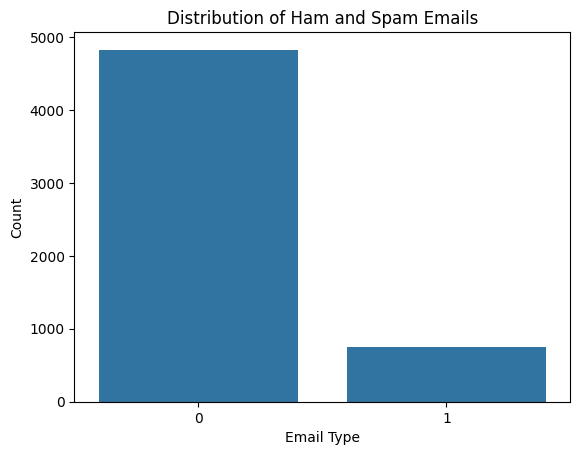

In [9]:
sns.countplot(x='Category', data=df)
plt.title("Distribution of Ham and Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

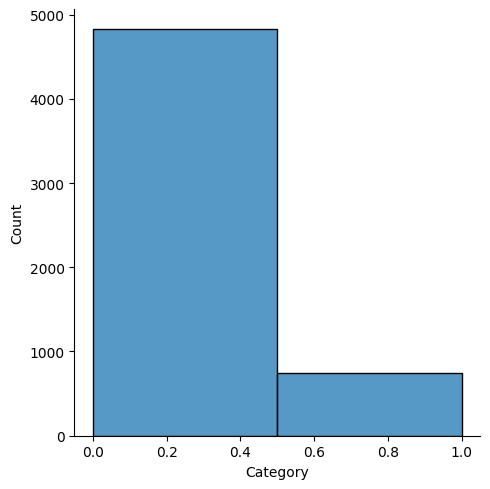

In [10]:
sns.displot(data=df, x='Category', kind='hist',bins=2)

In [11]:
X=df['Category']
y=df['Message']

CONVERT TEXT INTO NUMBERS

In [12]:
X = df['Message']      # Email text
y = df['Category']     # Spam/Ham label

In [13]:
# Features and Labels
X = df['Message'].astype(str)
y = df['Category']

# Convert text into numbers
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

print("Transformation Successful")
print(X.shape)

Transformation Successful
(5572, 8672)


TRAIN TEST SPLIT

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

MODEL TRAINING AND PREDICTION

In [15]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred= model.predict(X_test)

MODEL ACCURACY

In [16]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy",accuracy*100,"%")

Accuracy 96.23318385650225 %


CONFUSION METRIX

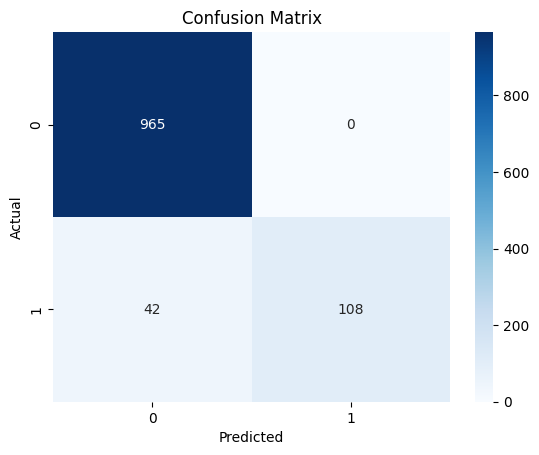

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

CLASSIFICATION REPORT

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



testing on email

In [19]:
email = ["Congratulations! You have won a free iPhone. Click now!"]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam Email")

Spam Email
